# Proyecto: Segmentador Inteligente de Clientes Minoristas

### Francisca Rojas González

## Objetivo del proyecto

El objetivo de este proyecto es aplicar técnicas de aprendizaje no supervisado,
especialmente clusterización, para identificar segmentos de clientes en un
dataset de comercio minorista. A través del uso de técnicas como reducción
de dimensionalidad y algoritmos de agrupamiento, se busca descubrir patrones
de comportamiento que permitan comprender mejor las características de los clientes.

### Dataset

El dataset contiene información de transacciones de clientes de una tienda minorista,
incluyendo variables relacionadas con frecuencia de compra, gasto total y
comportamiento de consumo.

## Reducción Dimensional y Preprocesamiento

### Carga y visualización de datos

In [1]:
# -------- CARGAR LIBRERÍAS Y FUNCIONES --------- #
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
# -------- CARGAR DATA: PRIMERA VISUALIZACIÓN --------- #
df = pd.read_csv("ecommerce_customer_behavior_dataset.csv")
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [4]:
# ------- REVISIÓN GENERAL COLUMNAS Y TIPO DE DATOS ---------
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   str    
 1   Customer_ID               5000 non-null   str    
 2   Date                      5000 non-null   str    
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   str    
 5   City                      5000 non-null   str    
 6   Product_Category          5000 non-null   str    
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   str    
 12  Device_Type               5000 non-null   str    
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Viewed       

In [5]:
# -------- VISUALIZACIÓN DE ESTADISTICAS GENERALES DE DATOS NUMÉRICOS --------
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


In [6]:
df['City'].value_counts()
df['Customer_ID'].nunique()

5000

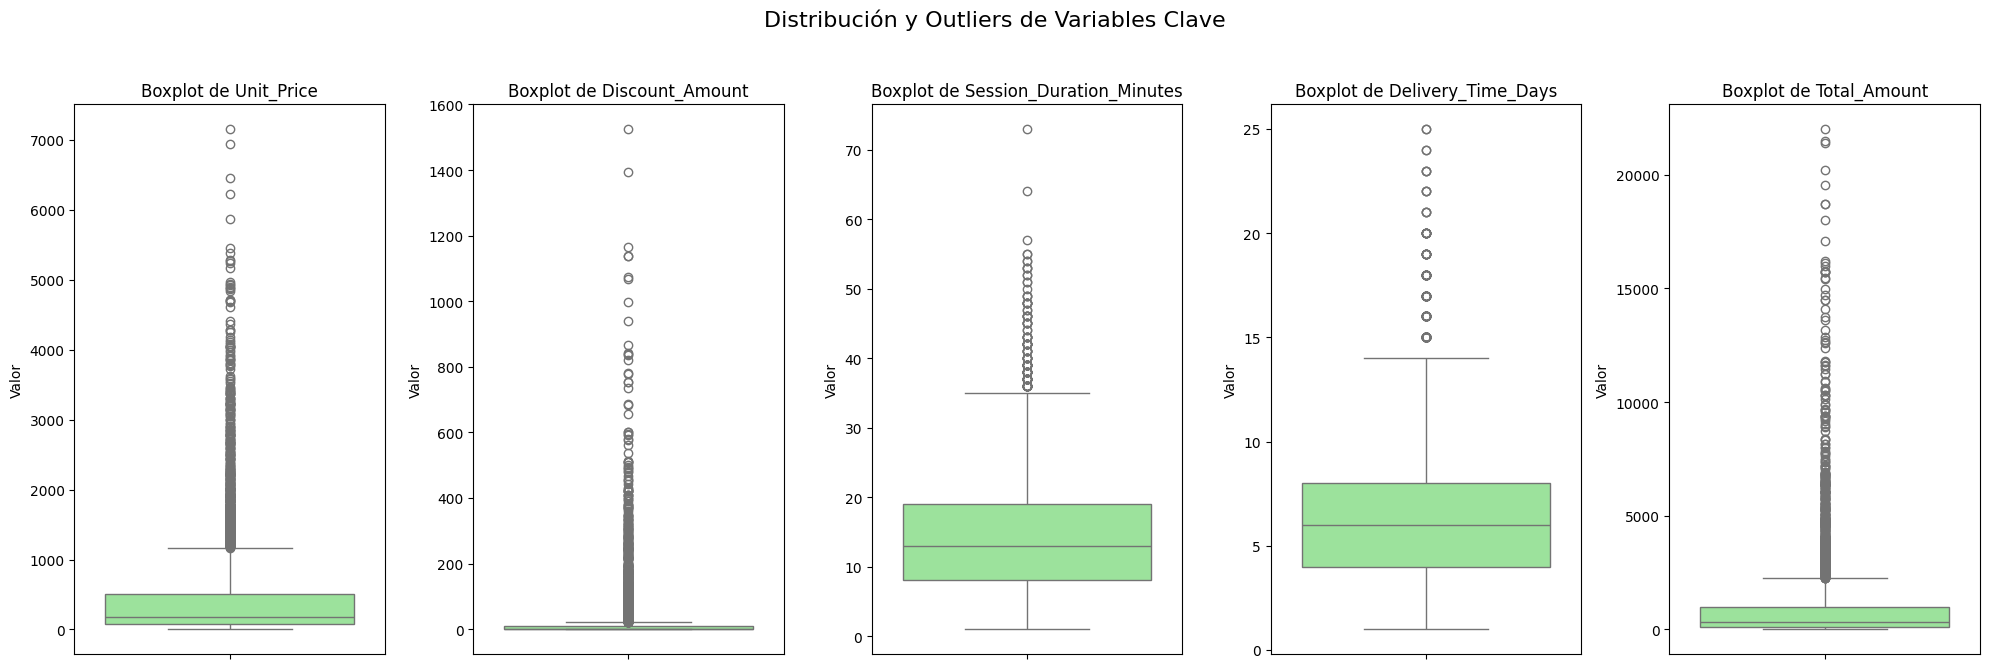

In [7]:
# ------- VISUALIZACIÓN OUTLIERS --------

# Seleccionamos las variables numéricas para observar presencia de outliers
vars_to_plot = ['Unit_Price', 'Discount_Amount', 'Session_Duration_Minutes', 'Delivery_Time_Days', 'Total_Amount']

# Configuración de la figura
fig, axes = plt.subplots(1, 5, figsize=(20, 7))
fig.suptitle('Distribución y Outliers de Variables Clave', fontsize=16)

# Generación de gráficos
for i, var in enumerate(vars_to_plot):
    sns.boxplot(y=df[var], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot de {var}')
    axes[i].set_ylabel('Valor')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Preprocesamiento: Decisiones 

Dado que este es un proyecto de segmentación de clientes, y mis datos son de pedidos, se buscó reducir a solo clientes, y al analizar el dataset se encontraron las siguientes características a tratar:
- Son todos los pedidos de diferentes clientes, por lo que, cada fila ya es un dato válido, no es necesario agruparlos.
- Las variables Order_ID, Customer_ID y Date, no son relevantes, serán eliminadas.
- Se encontraron outliers extremos que serán tratados con normalización logaritmica, para Total_Amount, Unit_Price y Discount_Amount.
- Hay variables categóricas que serán tratadas con OneHotEncoder, y 1/0 para booleanos.
- Se estandariza con StandarScaler.

In [8]:
# Eliminamos columnas irrelevantes
df_model = df.drop(columns=['Order_ID', 'Customer_ID', 'Date'])

# Convertimos booleanos a 1/0
df_model['Is_Returning_Customer'] = df_model['Is_Returning_Customer'].astype(int)

In [9]:
df_model

,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,1,8,5
1,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,1,3,3
2,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,1,5,2
3,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,0,1,4
4,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,1,7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Izmir,Beauty,130.35,1,27.30,103.05,Bank Transfer,Mobile,17,10,0,9,1
4996,27,Male,Adana,Beauty,71.55,1,0.00,71.55,Debit Card,Mobile,13,9,1,6,4
4997,45,Female,Antalya,Food,39.38,1,5.27,34.11,Digital Wallet,Mobile,38,10,1,5,4
4998,41,Female,Istanbul,Fashion,171.19,1,0.00,171.19,Credit Card,Mobile,20,12,1,5,4


In [10]:
# Aplicar logaritmo a variables con sesgo extremo 
cols_to_log = ['Total_Amount', 'Unit_Price', 'Discount_Amount']
#cols_to_log = ['Unit_Price', 'Discount_Amount', 'Session_Duration_Minutes', 'Delivery_Time_Days', 'Total_Amount']

for col in cols_to_log:
    df_model[col] = np.log1p(df_model[col])

In [11]:
# Definir qué columnas son categóricas y cuáles numéricas
cat_cols = ['Gender', 'City', 'Product_Category', 'Payment_Method', 'Device_Type']

# Todas las demás son numéricas
num_cols = [col for col in df_model.columns if col not in cat_cols]

# Configuramos el preprocesador
preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)])

# Aplicamos las transformaciones
data_prepared = preprocessor.fit_transform(df_model)

# Obtener nombres de columnas para el nuevo DataFrame (opcional, útil para análisis)
encoded_cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_col_names = list(num_cols) + list(encoded_cat_names)

df_final = pd.DataFrame(data_prepared, columns=all_col_names)

In [11]:
df_final

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,...,Product_Category_Food,Product_Category_Home & Garden,Product_Category_Sports,Product_Category_Toys,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet,Device_Type_Mobile,Device_Type_Tablet
0,-0.725001,-1.026007,-0.872319,-0.604894,-1.312753,-1.220259,1.788764,0.819903,0.433814,0.972325,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.628859,0.149716,-0.872319,-0.604894,-0.265020,-0.412400,-2.134120,0.819903,-1.009346,-0.800050,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.719116,-1.118594,1.987744,-0.604894,-0.276968,-0.874034,-0.350991,0.819903,-0.432082,-1.686238,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.273714,1.083978,-0.872319,2.455220,0.332236,-0.758625,0.362260,-1.219657,-1.586610,0.086137,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.448344,1.035084,1.987744,-0.604894,1.653037,0.741683,0.362260,0.819903,0.145182,0.086137,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,-1.537316,-0.344248,-0.872319,1.275779,-0.868771,0.280050,0.362260,-1.219657,0.722446,-2.572426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4996,-0.725001,-0.811846,-0.872319,-0.604894,-1.121906,-0.181584,0.005635,0.819903,-0.143450,0.086137,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4997,0.899631,-1.273420,-0.872319,0.427902,-1.631406,2.703625,0.362260,0.819903,-0.432082,0.086137,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4998,0.538601,-0.130979,-0.872319,-0.604894,-0.515158,0.626275,1.075512,0.819903,-0.432082,0.086137,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


### Implementar PCA

### Seleccionar componentes

- Regla del Codo → Mirar el gráfico y encontrar donde las mejoras dejan de ser significativas.
- Umbral de Varianza → Elegir suficientes componentes para explicar un porcentaje de información (80–95%).

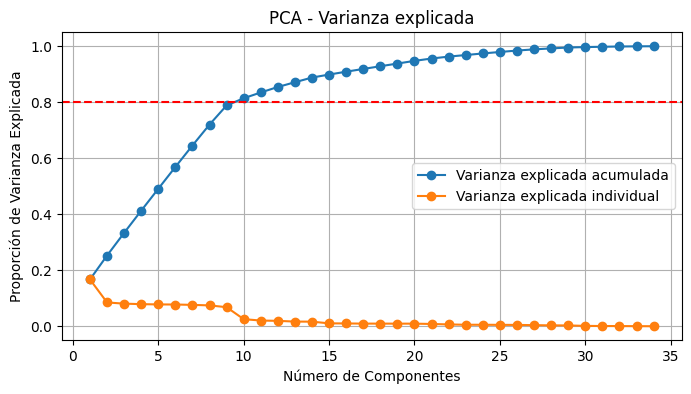

Componente 1: individual=0.1674 | acumulada=0.1674
Componente 2: individual=0.0853 | acumulada=0.2527
Componente 3: individual=0.0810 | acumulada=0.3337
Componente 4: individual=0.0792 | acumulada=0.4128
Componente 5: individual=0.0782 | acumulada=0.4910
Componente 6: individual=0.0779 | acumulada=0.5689
Componente 7: individual=0.0766 | acumulada=0.6455
Componente 8: individual=0.0747 | acumulada=0.7203
Componente 9: individual=0.0683 | acumulada=0.7886
Componente 10: individual=0.0256 | acumulada=0.8142
Componente 11: individual=0.0207 | acumulada=0.8349
Componente 12: individual=0.0196 | acumulada=0.8545
Componente 13: individual=0.0170 | acumulada=0.8715
Componente 14: individual=0.0167 | acumulada=0.8882
Componente 15: individual=0.0107 | acumulada=0.8988
Componente 16: individual=0.0103 | acumulada=0.9091
Componente 17: individual=0.0097 | acumulada=0.9188
Componente 18: individual=0.0097 | acumulada=0.9285
Componente 19: individual=0.0096 | acumulada=0.9381
Componente 20: indivi

In [12]:
# Elegir número óptimo mediante varianza explicada acumulada
pca_full = PCA().fit(data_prepared)
var_exp = pca_full.explained_variance_ratio_
var_acum = np.cumsum(var_exp)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(var_acum)+1), var_acum , marker='o', label='Varianza explicada acumulada')
plt.plot(range(1, len(var_exp) + 1), var_exp, marker='o', label='Varianza explicada individual')
plt.xlabel('Número de Componentes')
plt.ylabel('Proporción de Varianza Explicada')
plt.title("PCA - Varianza explicada")
plt.axhline(y=0.8, color='r', linestyle='--') # Umbral del 80%
plt.grid(True)
plt.legend()
plt.show()

# Mostrar valores de varianza por componente
for i, (v, va) in enumerate(zip(var_exp, var_acum), start=1):
    print(f"Componente {i}: individual={v:.4f} | acumulada={va:.4f}")

- El gráfico muestra que se necesita exactamente 10 componentes para alcanzar (y superar ligeramente 81.42%) el 80% de la varianza explicada.

- El "Codo" del PCA: Curva azul. Hay un cambio de pendiente importante alrededor del componente 9 o 10. A partir de ahí, cada componente nuevo que se agrega aporta muy poca información adicional (la curva se vuelve casi plana).

- Dimensionalidad Real: Aunque se comenzó con 16 variables originales, tras el One-Hot Encoding tu dataset creció (hasta 34 componentes). Sin embargo, este gráfico te dice que con solo 10 dimensiones se puede capturar la esencia del comportamiento de los clientes.

In [13]:
# PCA a 10 componentes
pca = PCA(n_components=10)
pca_results = pca.fit_transform(data_prepared)

### Implementar t-SNE

In [14]:
# t-SNE a 2 componentes
# Perplexity suele ser entre 5 y 50; ajustamos a 30 por defecto
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
tsne_results = tsne.fit_transform(data_prepared)

### Visualizar resultados

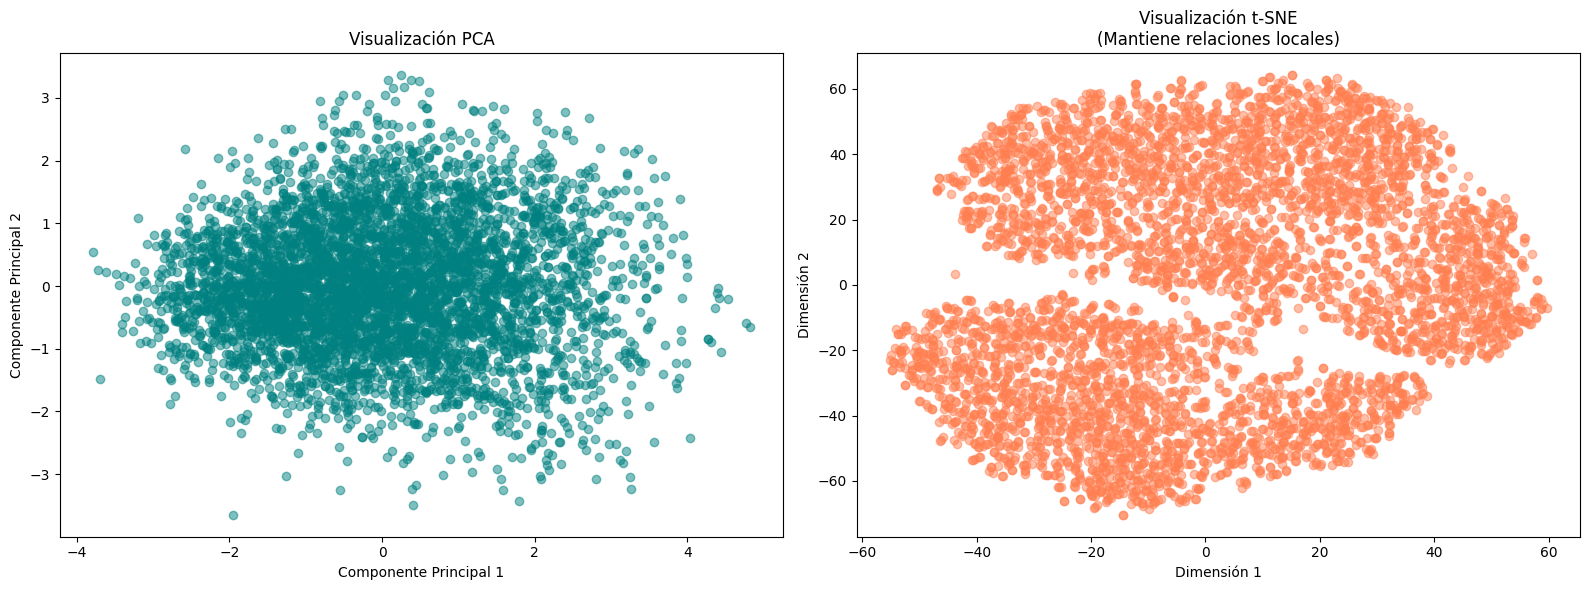

In [15]:
plt.figure(figsize=(16, 6))

# Subplot PCA (visualizar 2 componentes principales)
plt.subplot(1, 2, 1)
plt.scatter(pca_results[:, 0], pca_results[:, 1], alpha=0.5, c='teal')
plt.title(f'Visualización PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# Subplot t-SNE
plt.subplot(1, 2, 2)
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.5, c='coral')
plt.title('Visualización t-SNE\n(Mantiene relaciones locales)')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')

plt.tight_layout()
plt.show()

### Observación gráfico PCA
Se utilizaron las dos primeras componentes principales para la visualización 2D, las cuales representan las direcciones de máxima varianza de los datos. Aunque el clustering se realizó sobre un espacio de 10 dimensiones (asegurando retener el 80% de la información), la proyección en PC1 y PC2 permite observar la distribución global y la consistencia de los grupos asignados.

| Criterio | PCA (con 10 componentes) | t-SNE |
|---|---|---|
| Poder de Resumen | Captura el 80% de la varianza. Es excelente para reducir el ruido. | No mide varianza, pero "dibuja" la estructura. |
| Visualización | En 2D solo vimos el 25%. Para "verlo" bien necesitarías un gráfico de 10 dimensiones (imposible). | En 2D nos mostró grupos definidos. |
| Uso Posterior | **Ganador.** Es ideal para alimentar al K-Means, ya que reduce la dimensionalidad manteniendo la estructura global. | Solo para visualización. No se recomienda usar sus coordenadas para entrenar otros modelos. |

- Para Visualizar: t-SNE, dado que el PCA necesita 10 componentes para llegar al 80%, una proyección simple de 2 componentes de PCA no es suficiente para que el ojo humano vea los grupos, mientras que t-SNE sí los revela.

- Para el Clustering (K-Means/DBSCAN): PCA con 10 componentes. Se está eliminando el ruido y la redundancia de las 34 dimensiones originales, quedando con el "corazón" de los datos (el 80% de la varianza) para que el algoritmo de clusterización trabaje de forma más eficiente.

## Aplicación de Clusterización

## Búsqueda de número óptimo de clústeres
- Método del Codo
- Coeficiente de silueta

In [16]:
# Variables para elección de K con PCA 10 componentes
inertia = []
silhouette_vals = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pca_results)
    inertia.append(km.inertia_)
    silhouette_vals.append(silhouette_score(pca_results, labels))

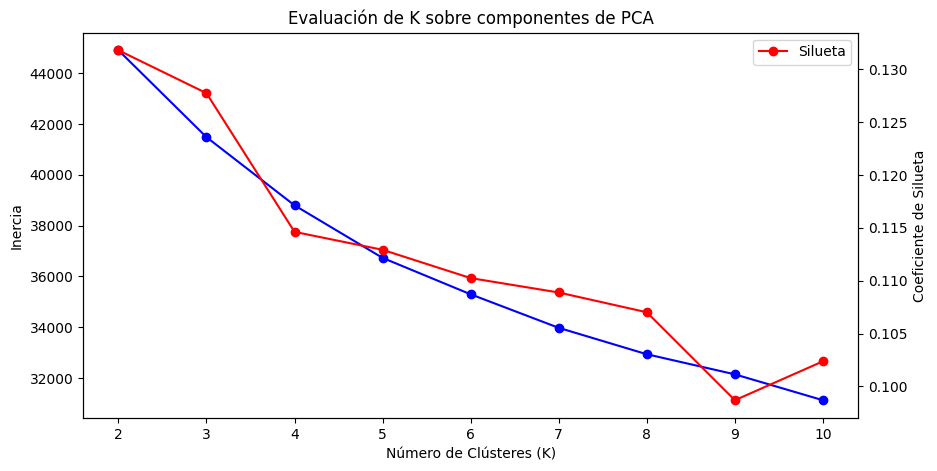

In [17]:
# Graficamos ambos para decidir
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(k_range, inertia, 'bo-', label='Inercia (Codo)')
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia')

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_vals, 'ro-', label='Silueta')
ax2.set_ylabel('Coeficiente de Silueta')

plt.title('Evaluación de K sobre componentes de PCA')
plt.legend()
plt.show()

#### Inercia (Línea Azul - Método del Codo)
Vemos caídas importantes de 2 a 3, y de 3 a 4. A partir de $K=5$, la pendiente se suaviza notablemente. El "codo" está en la zona del 3 o 4.

#### Coeficiente de Silueta (Línea Roja)
Mientras más alto, mejor. El valor máximo está en $K=2$, pero segmentar un mercado solo en dos grupos suele ser demasiado general para marketing. Hay un pico secundario muy claro en $K=3$. A partir de $K=4$, la silueta cae drásticamente, lo que indica que los grupos empiezan a solaparse o a volverse menos definidos.

**OBS**: Si bien el Silhouette de 0.128 es bajo, en datos de clientes de e-commerce es extremadamente común y no significa que el modelo sea "malo", sino que los clientes no se dividen en grupos aislados (como islas), sino que forman un continuo de comportamiento.

#### ¿Cuál $K$ conviene?
Para este proyecto, el número óptimo es $K=3$. 

$K=3$ ofrece el mejor equilibrio. Tiene un coeficiente de silueta significativamente más alto que $K=4$ (casi 0.128 frente a 0.114), lo que significa que los grupos en $K=3$ están mucho mejor separados y son más consistentes internamente.

Lógica de Negocio: En segmentación de clientes, $K=3$ es un número "mágico" inicial. Suele representar la estructura clásica de: 
- Clientes de alto valor/frecuentes.
- Clientes promedio/ocasionales.
- Clientes nuevos o de bajo gasto.

## Aplicación de algoritmos

In [21]:
# Configuración de los modelos
k_optimo = 3

# K-Means
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(pca_results)

# Agrupamiento Jerárquico (Ward minimiza la varianza dentro de grupos)
hierarchical = AgglomerativeClustering(n_clusters=k_optimo, linkage='ward')
labels_hierarchical = hierarchical.fit_predict(pca_results)

In [22]:
# Probar eps y min_samples para DBSCAN
eps_values = np.linspace(0.5, 3.0, 15) # Ampliamos el rango para explorar mejor
min_samples = 20 # Valor estándar para empezar

results = []

print(f"{'eps':<6} | {'clusters':<8} | {'ruido':<6} | {'silhouette':<10}")
print("-" * 45)

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(pca_results)

    # Identificar clusters (excluyendo el ruido -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    # Calcular silueta solo si hay al menos 2 clusters (sin contar el ruido)
    mask = labels != -1
    sil = None
    if n_clusters >= 2:
        sil = silhouette_score(pca_results[mask], labels[mask])
    
    results.append((eps, n_clusters, n_noise, sil))
    
    sil_txt = "NA" if sil is None else f"{sil:.3f}"
    print(f"{eps:<6.2f} | {n_clusters:<8} | {n_noise:<6} | {sil_txt:<10}")

eps    | clusters | ruido  | silhouette
---------------------------------------------
0.50   | 0        | 5000   | NA        
0.68   | 0        | 5000   | NA        
0.86   | 0        | 5000   | NA        
1.04   | 0        | 5000   | NA        
1.21   | 1        | 4980   | NA        
1.39   | 6        | 4372   | 0.099     
1.57   | 4        | 2917   | 0.073     
1.75   | 3        | 1617   | 0.080     
1.93   | 2        | 813    | 0.120     
2.11   | 1        | 359    | NA        
2.29   | 1        | 158    | NA        
2.46   | 1        | 76     | NA        
2.64   | 1        | 27     | NA        
2.82   | 1        | 10     | NA        
3.00   | 1        | 5      | NA        


- Se probó con min_samples = 5, 10, 20, 50
- El mejor adaptado a los 3 cluster buscados fue 20, con la menor cantidad de ruido posible y el mejor silhouette encontrado

In [19]:
# DBSCAN 
# Como se buscan 3 cluster, se eligió eps=1.75 y min_samples=20
dbscan = DBSCAN(eps=1.75, min_samples=20)
labels_dbscan = dbscan.fit_predict(pca_results)

## Visualización en 2D: con t-SNE y PCA 

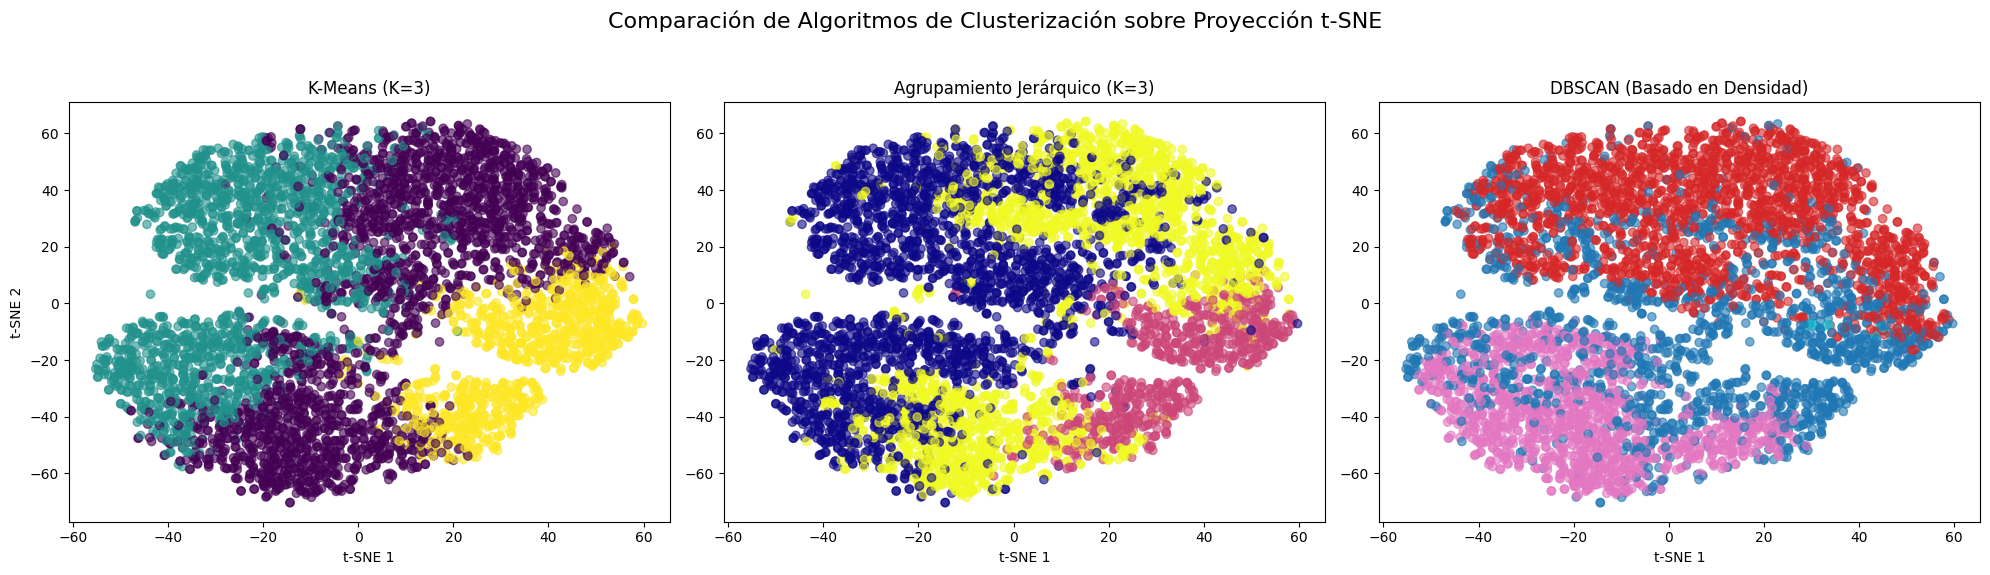

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Gráfico 1: K-Means
axes[0].scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels_kmeans, cmap='viridis', alpha=0.6)
axes[0].set_title(f'K-Means (K={k_optimo})')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Gráfico 2: Jerárquico
axes[1].scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels_hierarchical, cmap='plasma', alpha=0.6)
axes[1].set_title(f'Agrupamiento Jerárquico (K={k_optimo})')
axes[1].set_xlabel('t-SNE 1')

# Gráfico 3: DBSCAN
axes[2].scatter(tsne_results[:, 0], tsne_results[:, 1], c=labels_dbscan, cmap='tab10', alpha=0.6)
axes[2].set_title('DBSCAN (Basado en Densidad)')
axes[2].set_xlabel('t-SNE 1')

plt.suptitle('Comparación de Algoritmos de Clusterización sobre Proyección t-SNE', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

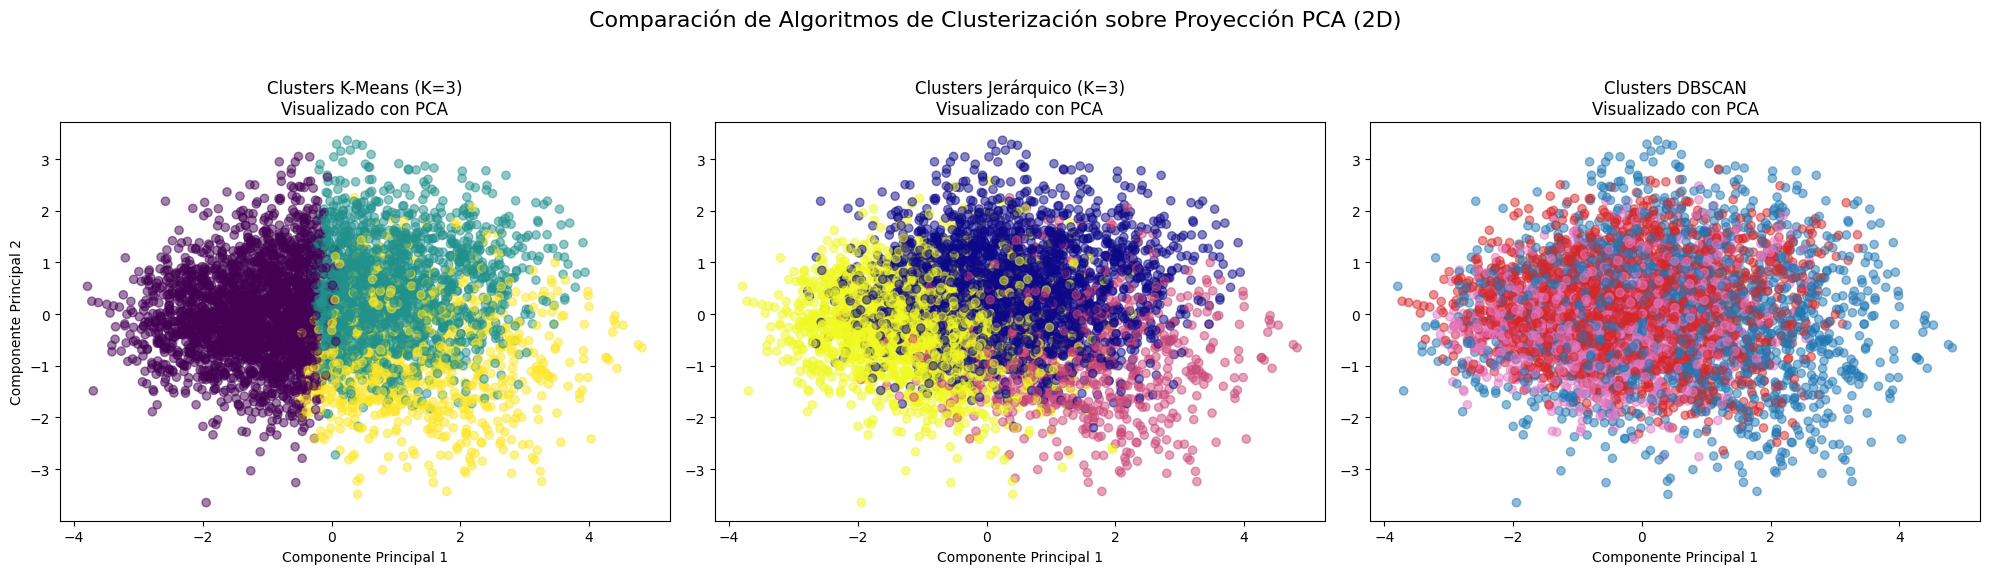

In [24]:
# Usamos las 2 primeras componentes del PCA que ya calculaste para el eje X e Y
# pca_results contiene la reducción a 2 dimensiones hecha al principio
x_axis = pca_results[:, 0]
y_axis = pca_results[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Visualización K-Means
axes[0].scatter(x_axis, y_axis, c=labels_kmeans, cmap='viridis', alpha=0.5)
axes[0].set_title(f'Clusters K-Means (K={k_optimo})\nVisualizado con PCA')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')

# 2. Visualización Agrupamiento Jerárquico
axes[1].scatter(x_axis, y_axis, c=labels_hierarchical, cmap='plasma', alpha=0.5)
axes[1].set_title(f'Clusters Jerárquico (K={k_optimo})\nVisualizado con PCA')
axes[1].set_xlabel('Componente Principal 1')

# 3. Visualización DBSCAN
# Nota: Los puntos en púrpura oscuro suelen ser el ruido (-1)
axes[2].scatter(x_axis, y_axis, c=labels_dbscan, cmap='tab10', alpha=0.5)
axes[2].set_title('Clusters DBSCAN\nVisualizado con PCA')
axes[2].set_xlabel('Componente Principal 1')

plt.suptitle('Comparación de Algoritmos de Clusterización sobre Proyección PCA (2D)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Análisis Individual de los Algoritmos
- K-Means, los grupos se dividen con cortes casi rectos (verticales/diagonales). Esto es porque K-Means intenta minimizar la distancia a un centroide, creando fronteras lineales. En t-SNE Los grupos se ven muy consistentes. El algoritmo logró capturar las "islas" naturales de datos. Es el que presenta los grupos más "limpios" visualmente.
- Agrupamiento Jerárquico, en el PCA, se nota que los grupos (especialmente el amarillo y el azul oscuro) están mucho más entrelazados que en K-Means. Este algoritmo es más flexible con las formas, pero en este dataset parece estar capturando sub-estructuras que se solapan. 
- DBSCAN, en t-SNE vemos que identifica una gran masa roja, una rosada y puntos azules dispersos. Los puntos azules dispersos son probablemente ruido o casos atípicos. DBSCAN nos dice que la mayoría de tus clientes tienen comportamientos muy similares (el gran bloque rojo), y solo unos pocos se separan realmente por densidad. No es el mejor para "forzar" una división de mercado igualitaria, pero es el mejor para encontrar outliers.

### Comparación de Resultados
- En PCA, los clústeres parecen mezclados. Esto confirma lo que vimos antes: como las 2 primeras componentes solo explican el 25% de la varianza, el ojo humano no puede ver la separación real que ocurre en las 10 dimensiones.
- En t-SNE, la separación es evidente. Esto justifica que la segmentación es real y sólida, pero ocurre por relaciones complejas (no lineales) entre las variables.
- K-Means ofrece segmentos mucho más compactos y fáciles de interpretar para un equipo de marketing. El jerárquico, al intentar agrupar por cercanía mínima o máxima, genera grupos con fronteras más difusas.

### Conclusión 
Para este sistema de segmentación de clientes de e-commerce, el algoritmo ganador es K-Means con $K=3$, según la claridad visual. En la proyección t-SNE, K-Means identifica tres regiones bien definidas que corresponden a comportamientos de compra diferenciados. A diferencia de DBSCAN, K-Means clasifica a todos los clientes, lo cual es vital para una estrategia comercial donde no queremos dejar clientes "sin etiqueta" (ruido).

Un modelo de 3 clústeres es altamente accionable. Permite diseñar tres estrategias distintas (ej: Retención para el grupo A, Venta Cruzada para el B y Fidelización para el C).

## Evaluación e Informe de Resultados

## Segmentaciones K-Means

In [25]:
# Añadimos las etiquetas de los algoritmos
df['Cluster_KMeans'] = labels_kmeans

# Creamos el perfilamiento 
perfiles_K = df.groupby('Cluster_KMeans').agg({
    'Cluster_KMeans': 'count',      # Cantidad de clientes por grupo
    'Age': 'mean',
    'Total_Amount': ['mean', 'sum'], # Promedio y aporte total al negocio
    'Customer_Rating': 'mean',
    'Session_Duration_Minutes': 'mean',
    'Is_Returning_Customer': 'mean',
    'Delivery_Time_Days': 'mean'    # Logística para ver satisfacción
}).round(2)

# Renombrar columnas para que sea legible
perfiles_K.columns = ['Nº_Clientes', 'Edad_Media', 'Gasto_Medio', 'Venta_Total', 'Valoración_Media', 
                      'Sesion_Media', 'Tasa_Retorno', 'Dias_Entrega_Media']

# Calcular el % de representación de cada grupo
perfiles_K['%_Clientes'] = (perfiles_K['Nº_Clientes'] / len(df) * 100).round(2)

perfiles_K

,Nº_Clientes,Edad_Media,Gasto_Medio,Venta_Total,Valoración_Media,Sesion_Media,Tasa_Retorno,Dias_Entrega_Media,%_Clientes
Cluster_KMeans,,,,,,,,,
0,2356,34.95,138.36,325978.96,3.90,14.70,0.58,6.53,47.12
1,1758,35.40,1802.10,3168090.44,3.88,14.27,0.61,6.53,35.16
2,886,34.52,1604.37,1421475.17,3.96,14.83,0.62,6.35,17.72


### K-Means 

- K-Means ha segmentado casi exclusivamente por el poder adquisitivo. Las otras cantidades son casi idénticas en los tres grupos.
- Cluster 0 (47%): Clientes de "bajo gasto" (138).
- Cluster 1 (35%) y Cluster 2 (17%): Clientes de alto valor (1,802 y 1,604).

In [26]:
# Añadimos las etiquetas de los algoritmos 
df['Cluster_hierarchical'] = labels_hierarchical

# Creamos el perfilamiento 
perfiles_H = df.groupby('Cluster_hierarchical').agg({
    'Cluster_hierarchical': 'count',      # Cantidad de clientes por grupo
    'Age': 'mean',
    'Total_Amount': ['mean', 'sum'], # Promedio y aporte total al negocio
    'Customer_Rating': 'mean',
    'Session_Duration_Minutes': 'mean',
    'Is_Returning_Customer': 'mean',
    'Delivery_Time_Days': 'mean'    # Agregamos logística para ver satisfacción
}).round(2)

# Renombrar columnas para que sea legible
perfiles_H.columns = ['Nº_Clientes', 'Edad_Media', 'Gasto_Medio', 'Venta_Total', 'Valoración_Media', 
                      'Sesion_Media', 'Tasa_Retorno', 'Dias_Entrega_Media']

# Calcular el % de representación de cada grupo
perfiles_H['%_Clientes'] = (perfiles_H['Nº_Clientes'] / len(df) * 100).round(2)

perfiles_H

,Nº_Clientes,Edad_Media,Gasto_Medio,Venta_Total,Valoración_Media,Sesion_Media,Tasa_Retorno,Dias_Entrega_Media,%_Clientes
Cluster_hierarchical,,,,,,,,,
0,2485,35.39,1299.88,3230197.66,3.96,13.30,0.60,6.86,49.70
1,711,33.62,1872.58,1331405.04,4.02,14.47,0.56,6.05,14.22
2,1804,35.09,196.20,353941.87,3.78,16.36,0.61,6.18,36.08


### Hierarchical

- A diferencia de K-Means, aquí vemos variaciones interesantes en la Sesion_Media. Este algoritmo detectó que el tiempo en la app es un diferenciador importante.
- Igualmente se ve una diferencia importante en el Gasto promedio en los 3 grupos.
- Cluster 2 (36%): Clientes con sesiones largas (16.3 min) pero gasto muy bajo ($196$). Podrían ser personas que comparan mucho antes y de no comprar casi nada.
- Cluster 0 (49%): El grupo más grande, con un gasto equilibrado ($1,299).

In [27]:
# Añadimos las etiquetas de los algoritmos
df['Cluster_dbscan'] = labels_dbscan

# Creamos el perfilamiento 
perfiles_D = df.groupby('Cluster_dbscan').agg({
    'Cluster_dbscan': 'count',      # Cantidad de clientes por grupo
    'Age': 'mean',
    'Total_Amount': ['mean', 'sum'], # Promedio y aporte total al negocio
    'Customer_Rating': 'mean',
    'Session_Duration_Minutes': 'mean',
    'Is_Returning_Customer': 'mean',
    'Delivery_Time_Days': 'mean'    # Agregamos logística para ver satisfacción
}).round(2)

# Renombrar columnas para que sea legible
perfiles_D.columns = ['Nº_Clientes', 'Edad_Media', 'Gasto_Medio', 'Venta_Total', 'Valoración_Media', 
                      'Sesion_Media', 'Tasa_Retorno', 'Dias_Entrega_Media']

# Calcular el % de representación de cada grupo
perfiles_D['%_Clientes'] = (perfiles_D['Nº_Clientes'] / len(df) * 100).round(2)

perfiles_D

,Nº_Clientes,Edad_Media,Gasto_Medio,Venta_Total,Valoración_Media,Sesion_Media,Tasa_Retorno,Dias_Entrega_Media,%_Clientes
Cluster_dbscan,,,,,,,,,
-1,1617,36.04,1718.39,2778638.32,3.47,17.68,0.53,7.66,32.34
0,2127,34.80,686.46,1460099.72,4.11,13.17,1.00,5.95,42.54
1,1243,34.10,531.68,660875.39,4.11,12.99,0.00,5.93,24.86
2,13,36.77,1225.47,15931.14,4.00,9.15,1.00,5.23,0.26


### DBSCAN 

- DBSCAN separó a los clientes por su lealtad y experiencia. Encontró quiénes son fieles, quiénes se perdieron y quiénes están insatisfechos (ruido).
- Cluster 0 (42%): Tasa de retorno de 1.00 (100% fieles).
- Cluster 1 (24%): Tasa de retorno de 0.00 (100% nuevos o que no vuelven).
- Cluster -1 (32%): El "ruido". Notar que este grupo tiene la valoración más baja (3.47) y el mayor tiempo de entrega (7.6 días).

### ¿Cuál es la mejor para este caso?

Si el objetivo es una estrategia integral de crecimiento, la mejor segmentación para este caso es K-Means, pero con una "mención especial" a DBSCAN.

¿Por qué K-Means?

Porque genera grupos con tamaños accionables (no deja un 32% en el aire como ruido) y diferencia claramente el valor del cliente. Para una empresa, es más fácil ejecutar: "Campaña para los que gastan +$1,500" que explicar grupos basados en densidades complejas.

Sin embargo, DBSCAN te acaba de dar un "insight" que K-Means ocultó, hay un 32% de clientes (Ruido) que están teniendo entregas lentas y calificando mal.

## Evaluación de modelos para los segmentos realizados

In [28]:
def eval_clustering(name, labels, X_used):
    """
    Calcula métricas de validación interna para los modelos de clusterización.
    Usa X_used para evaluar la cohesión y separación.
    """
    labels = np.asarray(labels)

    # Identificar máscara de ruido (importante para DBSCAN)
    mask = labels != -1
    noise_count = int((labels == -1).sum())
    
    # Datos filtrados (sin ruido para el cálculo de métricas)
    X_eval = X_used[mask]
    y_eval = labels[mask]

    n_clusters = len(set(y_eval))

    # Control de errores para métricas
    if n_clusters < 2:
        print(f"{name:15s} | Clusters: {n_clusters:2d} | Ruido: {noise_count:4d} | Sil:  NA  | DB:  NA  | CH:   NA")
        return

    # Cálculo de métricas
    sil = silhouette_score(X_eval, y_eval)           # ↑ Mayor es mejor
    db  = davies_bouldin_score(X_eval, y_eval)       # ↓ Menor es mejor
    ch  = calinski_harabasz_score(X_eval, y_eval)    # ↑ Mayor es mejor

    print(f"{name:15s} | Clusters: {n_clusters:2d} | Ruido: {noise_count:4d} | "
          f"Sil: {sil:.3f} | DB: {db:.3f} | CH: {ch:.1f}")

# Ejecución del reporte comparativo
print(f"{'Modelo':15s} | {'Clusters':8s} | {'Ruido':5s} | {'Sil(↑)':6s} | {'DB(↓)':6s} | {'CH(↑)':6s}")
print("-" * 80)

eval_clustering("K-Means", labels_kmeans, pca_results)
eval_clustering("Jerárquico", labels_hierarchical, pca_results)
eval_clustering("DBSCAN", labels_dbscan, pca_results)

Modelo          | Clusters | Ruido | Sil(↑) | DB(↓)  | CH(↑) 
--------------------------------------------------------------------------------
K-Means         | Clusters:  3 | Ruido:    0 | Sil: 0.128 | DB: 2.312 | CH: 638.2
Jerárquico      | Clusters:  3 | Ruido:    0 | Sil: 0.076 | DB: 2.884 | CH: 424.9
DBSCAN          | Clusters:  3 | Ruido: 1617 | Sil: 0.080 | DB: 2.130 | CH: 246.4


### Análisis de Métricas por Modelo

- K-Means: 
    - Silueta (0.128): Es el valor más alto de los tres. Esto confirma que, en promedio, los puntos de K-Means están más cerca de su centro y más lejos de los otros grupos.
    - Calinski-Harabasz (638.2): Supera por mucho a los demás. Esta métrica premia modelos donde la varianza entre grupos es alta y la interna es baja. Un valor de 638 indica una estructura de clústeres muy sólida.
    - Ruido (0): Clasifica al 100% de la población, lo que facilita la implementación comercial.


- Jerárquico: 
    - Silueta (0.076) y DB (2.884): Tiene el peor desempeño en ambas.
    - Un Davies-Bouldin cercano a 3 sugiere que los clústeres están muy "encimados" o que sus fronteras son muy borrosas.
    - Para este dataset de e-commerce, la jerarquía de proximidad no logra separar los comportamientos tan bien como los centroides de K-Means.


- DBSCAN: 
    - Davies-Bouldin (2.130): Es el mejor en esta métrica (el más bajo). Porque DBSCAN, al descartar 1617 puntos como ruido, solo mide la calidad de los núcleos "densos" que quedaron. Los grupos que sí encontró son extremadamente compactos.
    - Ruido (1617), se ha perdido al 32.3% de los datos. En un contexto de negocio, decir que no sabemos qué hacer con 1 de cada 3 clientes es un riesgo alto.


### Evaluación de Consistencia

La consistencia es la más alta para K-Means. Al comparar con los perfiles que sacados, vemos que el modelo no solo es matemáticamente superior (según esta tabla), sino que también es el que mejor separa por "Gasto Medio", que es la variable con mayor varianza en el negocio.

DBSCAN es consistente en encontrar "fidelidad" (aquellos con tasa de retorno 1.0), pero su inconsistencia radica en la incapacidad de procesar la masa crítica de clientes atípicos, lo que infla artificialmente su score de Davies-Bouldin.

### Conclusión y Elección del Modelo Final: El modelo elegido es K-Means ($K=3$).
Supera a los otros modelos en el Índice de Calinski-Harabasz (+50% respecto al Jerárquico) y en el Coeficiente de Silueta, demostrando una mejor definición de los segmentos. A diferencia de DBSCAN, K-Means permite una cobertura total de la base de datos de clientes sin generar pérdida de información (ruido). Las métricas confirman que $K=3$ genera grupos lo suficientemente distintos (baja similitud inter-clúster) para justificar estrategias de marketing diferenciadas.

## Recomendaciones Usos Comerciales

Basado en los perfiles de K-Means que vimos anteriormente:

- Segmento Valor (Gasto > $1,600): Implementar un Programa de Lealtad Premium. Este grupo representa el mayor ingreso por cliente; el objetivo es aumentar su frecuencia de compra.

- Segmento Masivo (Gasto ~$138): Estrategia de Cross-selling. Dado que su valoración es buena (3.9) pero su gasto es bajo, se deben recomendar productos complementarios para subir el ticket promedio.

- Alerta Logística (Hallazgo de DBSCAN): Aunque usemos K-Means, el reporte debe advertir que existe un grupo (el ruido de DBSCAN) con tiempos de entrega elevados (7.6 días) y baja calificación. Se recomienda auditar los procesos de despacho en las zonas donde estos clientes residen.

## Conclusiones

En este proyecto se aplicaron técnicas de aprendizaje no supervisado para analizar
patrones en datos de clientes minoristas. A través de métodos de reducción de
dimensionalidad y algoritmos de clusterización fue posible identificar grupos
de clientes con comportamientos similares.

Estos resultados permiten comprender mejor la estructura de los datos y
pueden servir como base para estrategias de marketing, segmentación de clientes
o personalización de servicios.

El aprendizaje no supervisado resulta especialmente útil cuando no existen
etiquetas previas, permitiendo descubrir patrones ocultos que pueden generar
valor en distintos contextos de análisis de datos.